# **Introdução**

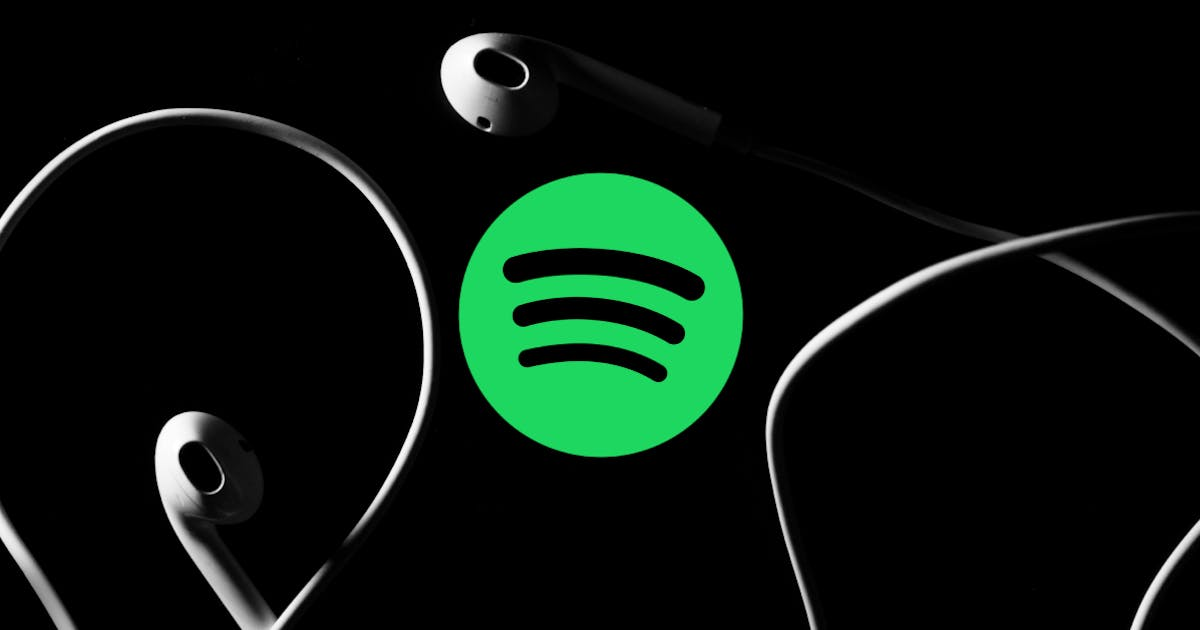

O Spotify é uma plataforma de streaming de música digital lançada em 2008 na Suécia. Criado para oferecer uma alternativa legal à pirataria musical, rapidamente se tornou um dos serviços mais populares do mundo. Hoje, o Spotify possui centenas de milhões de usuários e oferece um vasto catálogo de músicas, podcasts e playlists.

Este projeto analisa as características das músicas mais populares no Spotify de 2000 a 2019, explorando tendências e identificando o que torna uma música popular com base em suas características sonoras.

# **Importando bibliotecas e carregando dados**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
pd.options.mode.chained_assignment = None

In [3]:
spotify = pd.read_csv('songs_normalize.csv', sep = ',')
spotify.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


# **Análise Exploratória**

**Variáveis**

* artist: Nome do Artista.

* song: Nome da Música.

* duration_ms: Duração da música em milissegundos.

* explicit: A letra ou o conteúdo de uma música ou videoclipe contém um ou mais dos critérios que podem ser considerados ofensivos ou inadequados para crianças.

* year: Ano de lançamento da música.

* popularity: Quanto maior o valor, mais popular é a música.

* danceability: A dançabilidade descreve o quão adequada uma música é para dançar, com base em uma combinação de elementos musicais, incluindo andamento, estabilidade rítmica, intensidade da batida e regularidade geral. Um valor de 0,0 é o menos dançável e 1,0 é o mais dançável.

* energy: A energia é uma medida de 0,0 a 1,0 e representa uma medida perceptiva de intensidade e atividade.

* key: A tonalidade da música. Os números inteiros correspondem às notas usando a notação padrão de Classe de Altura. Por exemplo, 0 = Dó, 1 = Dó sustenido/Ré bemol, 2 = Ré e assim por diante. Se nenhuma tonalidade for detectada, o valor é -1.

* loudness: A intensidade sonora geral de uma faixa em decibéis (dB). Os valores de intensidade sonora são calculados como a média de toda a faixa e são úteis para comparar a intensidade sonora relativa de diferentes faixas. A intensidade sonora é a qualidade de um som que é o principal correlato psicológico da força física (amplitude). Os valores normalmente variam entre -60 e 0 dB.

* mode: O modo indica a modalidade (maior ou menor) de uma faixa, o tipo de escala da qual seu conteúdo melódico é derivado. Maior é representado por 1 e menor por 0.

* speechiness: A presença de fala detecta a presença de palavras faladas em uma faixa. Quanto mais exclusivamente semelhante à fala for a gravação (por exemplo, talk show, audiolivro, poesia), mais próximo de 1,0 será o valor do atributo. Valores acima de 0,66 descrevem faixas que provavelmente são compostas inteiramente de palavras faladas. Valores entre 0,33 e 0,66 descrevem faixas que podem conter música e fala, seja em seções ou em camadas, incluindo casos como música rap. Valores abaixo de 0,33 provavelmente representam música e outras faixas que não são semelhantes à fala.

* acousticness: Uma medida de confiança de 0,0 a 1,0 que indica se a faixa é acústica. 1,0 representa alta confiança de que a faixa é acústica.

* instrumentalness: Prevê se uma faixa não contém vocais. Sons como "Ooh" e "aah" são tratados como instrumentais neste contexto. Faixas de rap ou spoken word são claramente "vocais". Quanto mais próximo o valor de instrumentalidade estiver de 1,0, maior a probabilidade de a faixa não conter conteúdo vocal. Valores acima de 0,5 representam faixas instrumentais, mas a confiança é maior à medida que o valor se aproxima de 1,0.

* liveness: Detecta a presença de público na gravação. Valores de "ao vivo" mais altos representam uma maior probabilidade de a faixa ter sido executada ao vivo. Um valor acima de 0,8 indica uma alta probabilidade de a faixa ser ao vivo.

* valence: Uma medida de 0,0 a 1,0 que descreve a positividade musical transmitida por uma faixa. Faixas com alta valência soam mais positivas (por exemplo, alegres, animadas, eufóricas), enquanto faixas com baixa valência soam mais negativas (por exemplo, tristes, deprimidas, raivosas).

* tempo: O andamento geral estimado de uma faixa em batidas por minuto (BPM). Em terminologia musical, andamento é a velocidade ou o ritmo de uma determinada peça e deriva diretamente da duração média da batida.

* genre: Gênero da faixa.


In [4]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   object 
 1   song              2000 non-null   object 
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 non-null   float64


In [5]:
spotify.isnull().sum()

,0
artist,0
song,0
duration_ms,0
explicit,0
year,0
popularity,0
danceability,0
energy,0
key,0
loudness,0


In [6]:
spotify.duplicated().sum()

np.int64(59)

In [7]:
spotify.drop_duplicates(inplace = True)

In [8]:
spotify.describe()

,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,228594.973725,2009.520350,59.633179,0.667814,0.721549,5.369397,-5.514082,0.553323,0.103783,0.128173,0.015372,0.181726,0.552966,120.158442
std,39249.796103,5.875532,21.501053,0.140608,0.152872,3.615270,1.938950,0.497277,0.096148,0.172584,0.088371,0.140910,0.220845,26.990475
min,113000.000000,1998.000000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,0.000019,0.000000,0.021500,0.038100,60.019000
25%,203506.000000,2004.000000,56.000000,0.581000,0.624000,2.000000,-6.490000,0.000000,0.039700,0.013500,0.000000,0.088400,0.390000,98.986000
50%,223186.000000,2010.000000,65.000000,0.676000,0.739000,6.000000,-5.285000,1.000000,0.061000,0.055800,0.000000,0.124000,0.560000,120.028000
75%,247946.000000,2015.000000,73.000000,0.765000,0.840000,8.000000,-4.168000,1.000000,0.129000,0.176000,0.000069,0.242000,0.731000,134.199000
max,484146.000000,2020.000000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,0.976000,0.985000,0.853000,0.973000,210.851000


**Convertendo a duração de milissegundos para minutos**

In [9]:
spotify['duration_ms'] = (spotify['duration_ms'] / 60000).round(2)
spotify['duration_min'] = spotify['duration_ms'].astype(int)
spotify['duration_seg'] = spotify['duration_ms'] - spotify['duration_min']
spotify['duration_seg'] = (spotify['duration_seg'] * 60).round(2).astype(int)
spotify['duration'] = spotify['duration_min'].astype(str) + ':' + spotify['duration_seg'].astype(str)

spotify.drop(['duration_min', 'duration_seg'], axis = 1, inplace = True)
spotify.head()

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre,duration
0,Britney Spears,Oops!...I Did It Again,3.52,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop,3:31
1,blink-182,All The Small Things,2.78,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop",2:46
2,Faith Hill,Breathe,4.18,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country",4:10
3,Bon Jovi,It's My Life,3.74,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal",3:44
4,*NSYNC,Bye Bye Bye,3.34,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop,3:20


# **Distribuição e Frequência**

In [10]:
spotify_frequency = spotify[['song', 'year', 'genre']]
spotify_frequency_year = spotify_frequency.groupby('year').agg({
    'song' : 'count'
  }).reset_index()

spotify_frequency_genre = spotify_frequency.groupby('genre').agg({
    'song' : 'count'
  }).reset_index()
spotify_frequency_genre.sort_values('song', ascending = False, inplace = True)

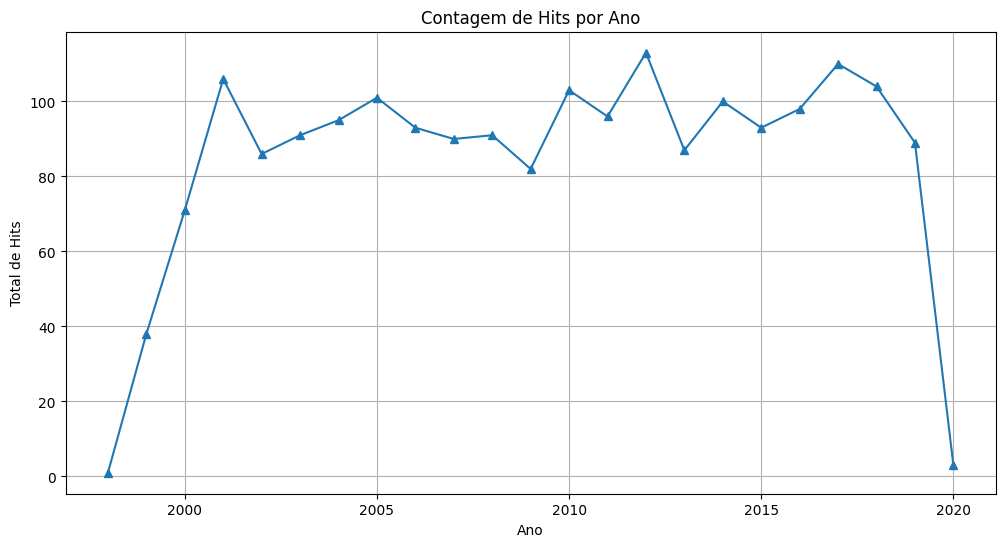

In [11]:
fig, ax = plt.subplots(figsize = (12, 6))
plt.plot(spotify_frequency_year['year'], spotify_frequency_year['song'], marker = '^')
plt.title('Contagem de Hits por Ano')
plt.xlabel('Ano')
plt.ylabel('Total de Hits')
plt.grid()
plt.show()

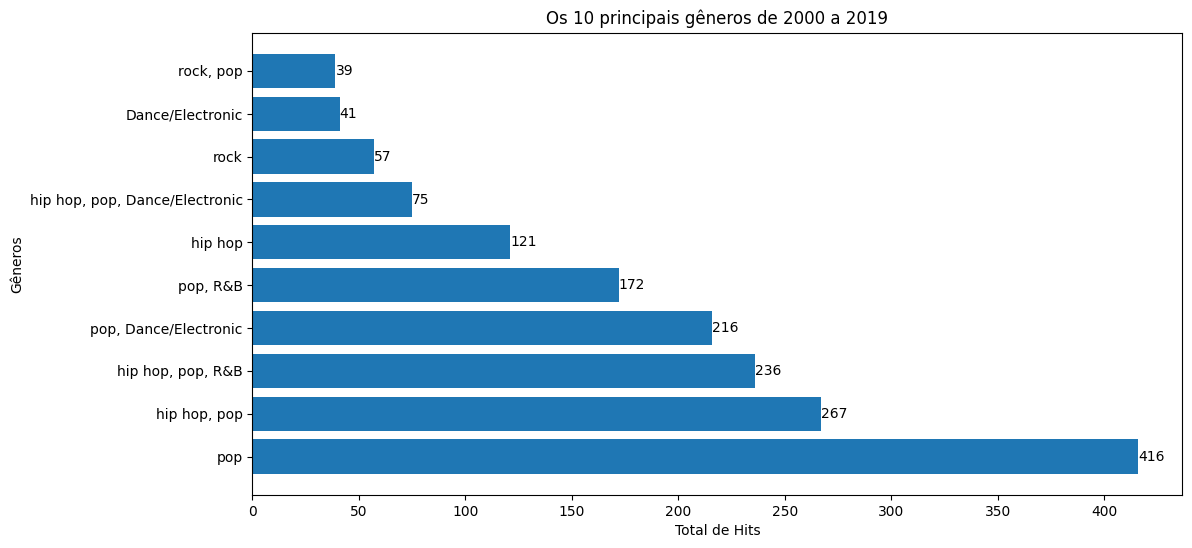

In [12]:
top10_spotify_frequency_genre = spotify_frequency_genre.iloc[:10]

fig, ax = plt.subplots(figsize = (12, 6))
t = ax.barh(top10_spotify_frequency_genre['genre'], top10_spotify_frequency_genre['song'])
plt.title('Os 10 principais gêneros de 2000 a 2019')
plt.xlabel('Total de Hits')
plt.ylabel('Gêneros')
plt.bar_label(t, label_type = 'edge')
plt.show()

**Principais gêneros por ano**

In [13]:
spotify_frequency_first_genre_year = spotify_frequency.groupby(['year', 'genre']).agg({
    'song' : 'count'
  }).reset_index().sort_values('song', ascending = False)

spotify_frequency_first_genre_year = spotify_frequency_first_genre_year.groupby('year').first().sort_values('year', ascending = True)
spotify_frequency_first_genre_year

,genre,song
year,,
1998,"hip hop, pop, R&B",1
1999,pop,11
2000,pop,16
2001,pop,25
2002,"hip hop, pop, R&B",26
2003,"hip hop, pop",17
2004,"pop, R&B",15
2005,"hip hop, pop",20
2006,pop,24


# **Ranking de Popularidade**

In [14]:
spotify_popularity = spotify[['year', 'artist', 'song', 'genre', 'popularity']]
spotify_popularity['song_artist'] = spotify_popularity['artist'] + ' - ' + spotify_popularity['song']
spotify_popularity.drop(['song'], axis = 1, inplace = True)
spotify_popularity.head()

,year,artist,genre,popularity,song_artist
0,2000,Britney Spears,pop,77,Britney Spears - Oops!...I Did It Again
1,1999,blink-182,"rock, pop",79,blink-182 - All The Small Things
2,1999,Faith Hill,"pop, country",66,Faith Hill - Breathe
3,2000,Bon Jovi,"rock, metal",78,Bon Jovi - It's My Life
4,2000,*NSYNC,pop,65,*NSYNC - Bye Bye Bye


**Música mais popular do ano**

In [15]:
spotify_popularity_year = spotify_popularity[['year', 'song_artist', 'popularity']]
spotify_popularity_year.sort_values('popularity', ascending = False, inplace = True)
spotify_popularity_year.groupby('year').first().sort_values('year', ascending = True)

,song_artist,popularity
year,,
1998,Missy Elliott - Hot Boyz,49
1999,Dr. Dre - The Next Episode,82
2000,Eminem - The Real Slim Shady,86
2001,Jimmy Eat World - The Middle,78
2002,Eminem - Without Me,87
2003,Linkin Park - Numb,81
2004,Usher - Yeah! (feat. Lil Jon & Ludacris),81
2005,Gorillaz - Feel Good Inc.,82
2006,Nelly Furtado - Promiscuous,82


**Música mais popular por gênero**

In [16]:
spotify_popularity_genre = spotify_popularity[['genre', 'song_artist', 'popularity']]
spotify_popularity_genre.sort_values('popularity', ascending = False, inplace = True)
spotify_popularity_genre.groupby('genre').first().sort_values('popularity', ascending = False)

,song_artist,popularity
genre,,
"rock, pop",The Neighbourhood - Sweater Weather,89
pop,Tom Odell - Another Love,88
hip hop,Eminem - Without Me,87
"pop, Dance/Electronic",Billie Eilish - lovely (with Khalid),86
"pop, R&B, Dance/Electronic",WILLOW - Wait a Minute!,86
"pop, R&B",The Weeknd - The Hills,84
rock,Arctic Monkeys - Do I Wanna Know?,84
"hip hop, pop, R&B",Drake - One Dance,84
Dance/Electronic,Gesaffelstein - Lost in the Fire (feat. The We...,84


**Os 20 maiores artistas de 2000 a 2019**

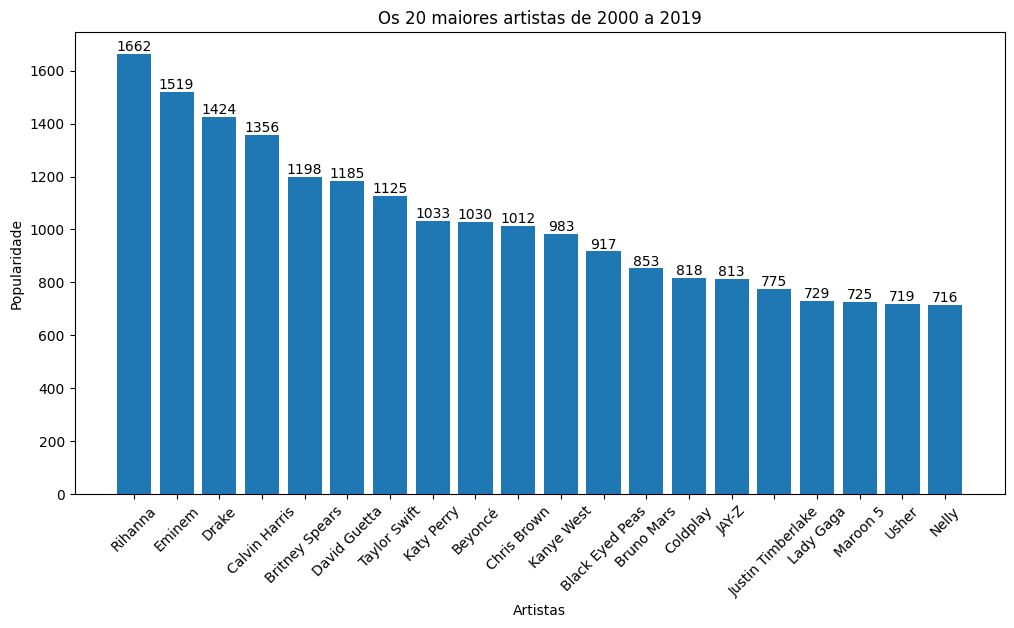

In [17]:
spotify_popularity_artist = spotify_popularity[['artist', 'song_artist', 'popularity']]
spotify_popularity_artist = spotify_popularity_artist.groupby('artist').agg({
    'popularity' : 'sum',
    'song_artist' : 'count'
  }).reset_index()

spotify_popularity_artist.sort_values('popularity', ascending = False, inplace = True)
spotify_popularity_artist = spotify_popularity_artist.groupby('artist').first().sort_values('popularity', ascending = False)

fig, ax = plt.subplots(figsize = (12, 6))
s = plt.bar(spotify_popularity_artist.index[:20], spotify_popularity_artist['popularity'][:20])
plt.title('Os 20 maiores artistas de 2000 a 2019')
plt.xlabel('Artistas')
plt.ylabel('Popularidade')
plt.bar_label(s, label_type = 'edge')
plt.xticks(rotation = 45)
plt.show()

**Os 20 maiores hits de 2000 a 2019**

In [18]:
spotify_popularity_song = spotify_popularity[['year', 'song_artist', 'popularity']]
spotify_popularity_song.sort_values('popularity', ascending = False, inplace = True)
spotify_popularity_song.iloc[:20]

,year,song_artist,popularity
1322,2013,The Neighbourhood - Sweater Weather,89
1311,2013,Tom Odell - Another Love,88
201,2002,Eminem - Without Me,87
1613,2015,WILLOW - Wait a Minute!,86
1819,2018,Billie Eilish - lovely (with Khalid),86
6,2000,Eminem - The Real Slim Shady,86
1999,2019,Post Malone - Circles,85
1514,2014,Avicii - The Nights,85
1512,2015,The Neighbourhood - Daddy Issues,85
1709,2017,Ed Sheeran - Perfect,85


# **Duração**

In [19]:
spotify_duration = spotify[['song', 'artist', 'duration_ms']]
spotify_duration.head()

,song,artist,duration_ms
0,Oops!...I Did It Again,Britney Spears,3.52
1,All The Small Things,blink-182,2.78
2,Breathe,Faith Hill,4.18
3,It's My Life,Bon Jovi,3.74
4,Bye Bye Bye,*NSYNC,3.34


In [20]:
spotify_duration['duration_min'] = spotify_duration['duration_ms'].astype(int)
spotify_duration['duration_seg'] = spotify_duration['duration_ms'] - spotify_duration['duration_min']
spotify_duration['duration_seg'] = (spotify_duration['duration_seg'] * 60).round(2).astype(int)
spotify_duration['duration'] = spotify_duration['duration_min'].astype(str) + ':' + spotify_duration['duration_seg'].astype(str)

spotify_duration.drop(['duration_min', 'duration_seg'], axis = 1, inplace = True)
spotify_duration.sort_values('duration_ms', ascending = False, inplace = True)
spotify_duration['song_artist'] = spotify_duration['artist'] + ' - ' + spotify_duration['song']
spotify_duration.head()

,song,artist,duration_ms,duration,song_artist
1381,Mirrors,Justin Timberlake,8.07,8:4,Justin Timberlake - Mirrors
140,Another Chance,Roger Sanchez,7.55,7:33,Roger Sanchez - Another Chance
706,What Goes Around.../...Comes Around (Interlude),Justin Timberlake,7.48,7:28,Justin Timberlake - What Goes Around.../...Com...
760,LoveStoned / I Think She Knows (Interlude),Justin Timberlake,7.41,7:24,Justin Timberlake - LoveStoned / I Think She K...
242,Days Go By,Dirty Vegas,7.20,7:12,Dirty Vegas - Days Go By


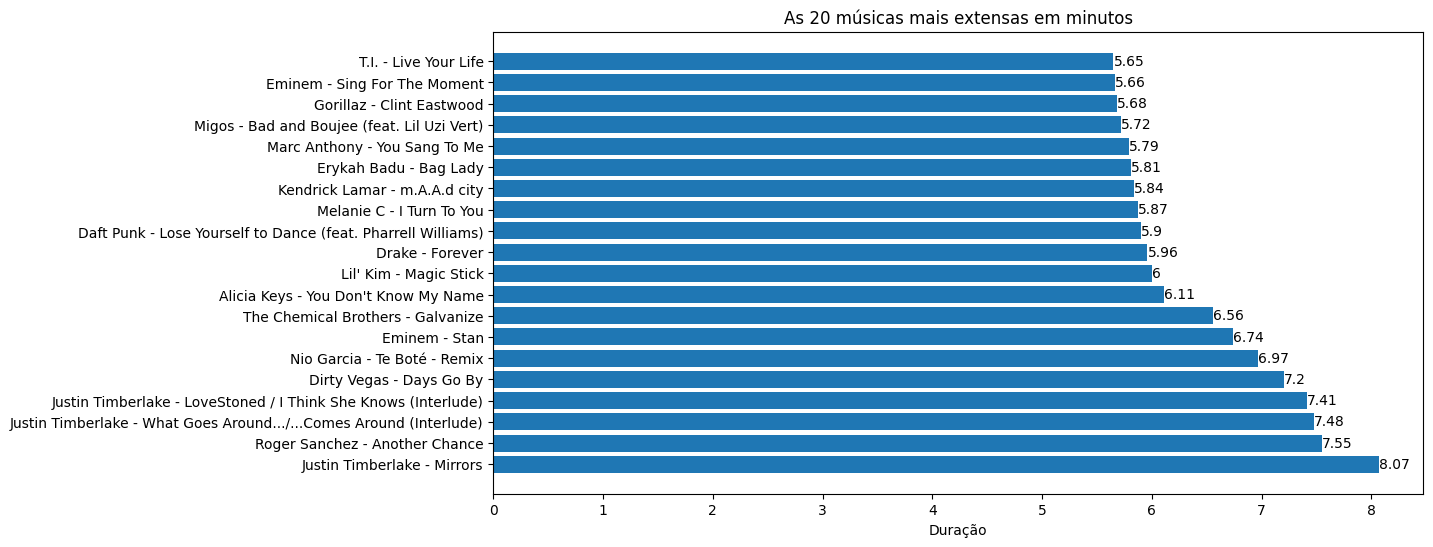

In [21]:
fig, ax = plt.subplots(figsize = (12, 6))
s = plt.barh(spotify_duration['song_artist'][:20], spotify_duration['duration_ms'][:20])
plt.title('As 20 músicas mais extensas em minutos')
plt.xlabel('Duração')
plt.bar_label(s, label_type = 'edge')
plt.show()

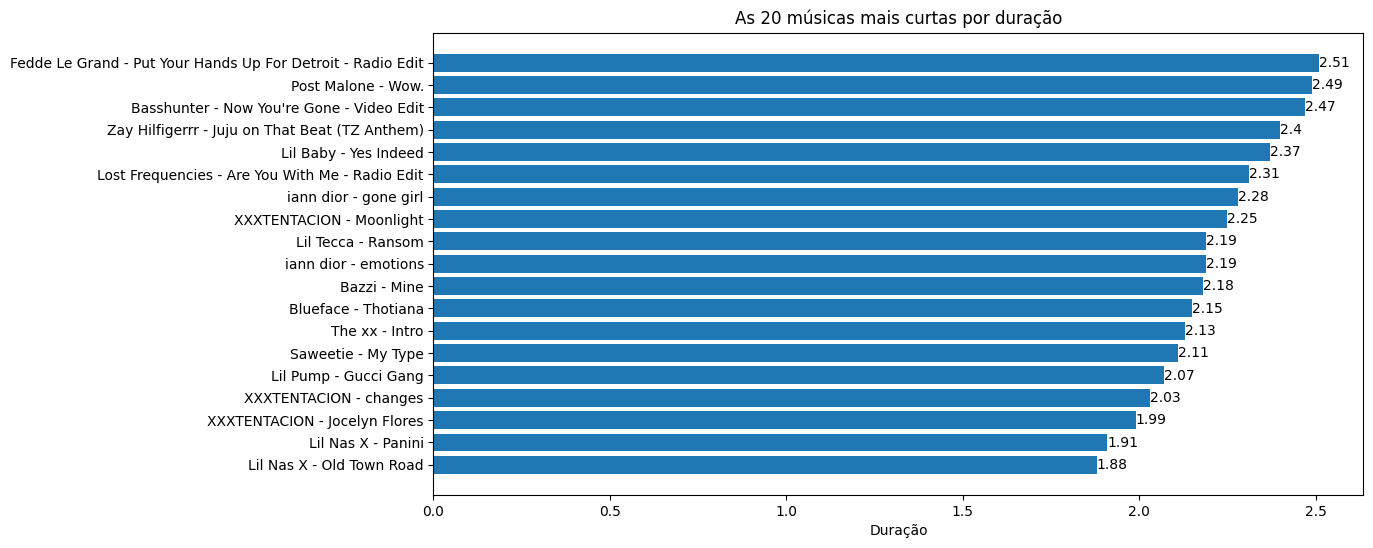

In [22]:
spotify_duration.sort_values('duration_ms', ascending = True, inplace = True)

fig, ax = plt.subplots(figsize = (12, 6))
s = plt.barh(spotify_duration['song_artist'][:19], spotify_duration['duration_ms'][:19])
plt.title('As 20 músicas mais curtas por duração')
plt.xlabel('Duração')
plt.bar_label(s, label_type = 'edge')
plt.show()

# **Medições e comparações**

In [23]:
comp_spotify = spotify[['year', 'genre', 'duration_ms', 'explicit', 'popularity']]
comp_spotify.head()

,year,genre,duration_ms,explicit,popularity
0,2000,pop,3.52,False,77
1,1999,"rock, pop",2.78,False,79
2,1999,"pop, country",4.18,False,66
3,2000,"rock, metal",3.74,False,78
4,2000,pop,3.34,False,65


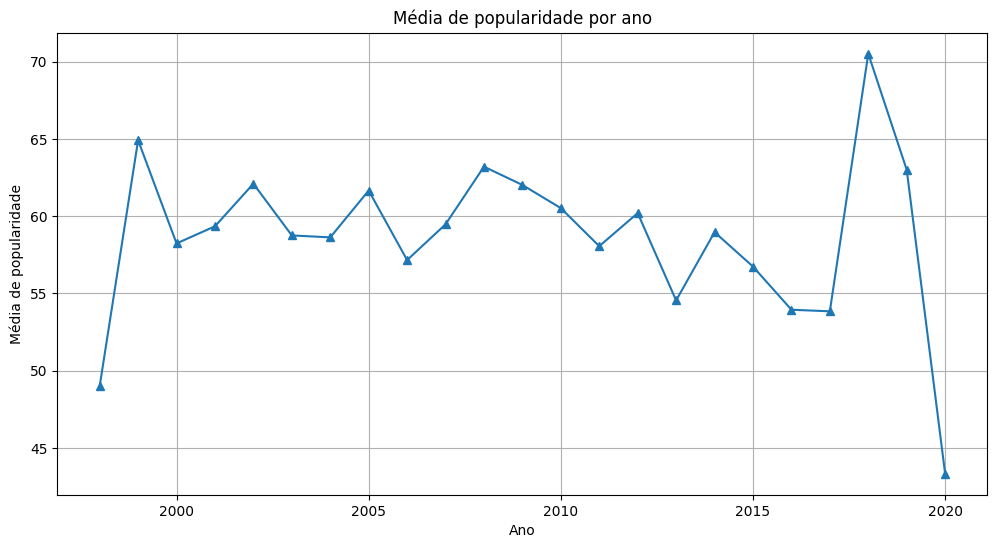

In [41]:
spotify_avg_year = comp_spotify.groupby('year').agg({
    'popularity' : 'mean'
  }).reset_index()

fig, ax = plt.subplots(figsize = (12, 6))
plt.plot(spotify_avg_year['year'], spotify_avg_year['popularity'], marker = '^')
plt.title('Média de popularidade por ano')
plt.xlabel('Ano')
plt.ylabel('Média de popularidade')
plt.grid()

**Média de popularidade por gênero**

In [25]:
spotify_avg_genre = comp_spotify.groupby('genre').agg({
    'popularity' : 'mean'
  }).reset_index()

spotify_avg_genre.sort_values('popularity', ascending = False, inplace = True)
spotify_avg_genre

,genre,popularity
42,"pop, rock, Folk/Acoustic",79.000000
1,"Folk/Acoustic, pop",78.000000
57,"rock, pop, metal, Dance/Electronic",76.000000
27,"hip hop, rock, pop",75.000000
29,metal,72.000000
18,"hip hop, latin, Dance/Electronic",72.000000
13,easy listening,72.000000
47,"rock, Folk/Acoustic, pop",71.000000
53,"rock, metal",70.527778
5,"World/Traditional, Folk/Acoustic",69.000000


**Média de duração por gênero**

In [26]:
spotify_avg_genre_duration = comp_spotify.groupby('genre').agg({
    'duration_ms' : 'mean'
  }).reset_index()

spotify_avg_genre_duration['duration_min'] = spotify_avg_genre_duration['duration_ms'].astype(int)
spotify_avg_genre_duration['duration_seg'] = spotify_avg_genre_duration['duration_ms'] - spotify_avg_genre_duration['duration_min']
spotify_avg_genre_duration['duration_seg'] = (spotify_avg_genre_duration['duration_seg'] * 60).round(2).astype(int)
spotify_avg_genre_duration['duration'] = spotify_avg_genre_duration['duration_min'].astype(str) + ':' + spotify_avg_genre_duration['duration_seg'].astype(str)
spotify_avg_genre_duration.drop(['duration_min', 'duration_seg'], axis = 1, inplace = True)

spotify_avg_genre_duration.sort_values('duration_ms', ascending = False, inplace = True)
spotify_avg_genre_duration

,genre,duration_ms,duration
13,easy listening,5.040000,5:2
2,"Folk/Acoustic, rock",4.640000,4:38
18,"hip hop, latin, Dance/Electronic",4.280000,4:16
24,"hip hop, pop, country",4.210000,4:12
35,"pop, R&B, easy listening",4.170000,4:10
43,"pop, rock, metal",4.161429,4:9
9,"World/Traditional, rock",4.155000,4:9
49,"rock, blues",4.120000,4:7
3,"Folk/Acoustic, rock, pop",4.090000,4:5
57,"rock, pop, metal, Dance/Electronic",4.070000,4:4


**Explícito x Não-explícito - Qual tipo mais popular?**

In [27]:
comp_spotify.groupby('explicit').agg({
    'popularity' : 'mean'
  }).reset_index()

,explicit,popularity
0,False,59.004274
1,True,61.277467


**Contagem de músicas explícitas e não-explícitas por ano**

In [28]:
comp_spotify['explicit_label'] = comp_spotify['explicit'].apply(lambda x: 'Explicit' if x == True else 'No-explicit')
comp_spotify_explicit = comp_spotify.groupby(['year', 'explicit_label']).size().reset_index(name = 'count')
comp_spotify_explicit = comp_spotify_explicit.pivot_table(index = 'year', columns= 'explicit_label', values = 'count').fillna(0).astype(int)
comp_spotify_explicit.reset_index(inplace = True)

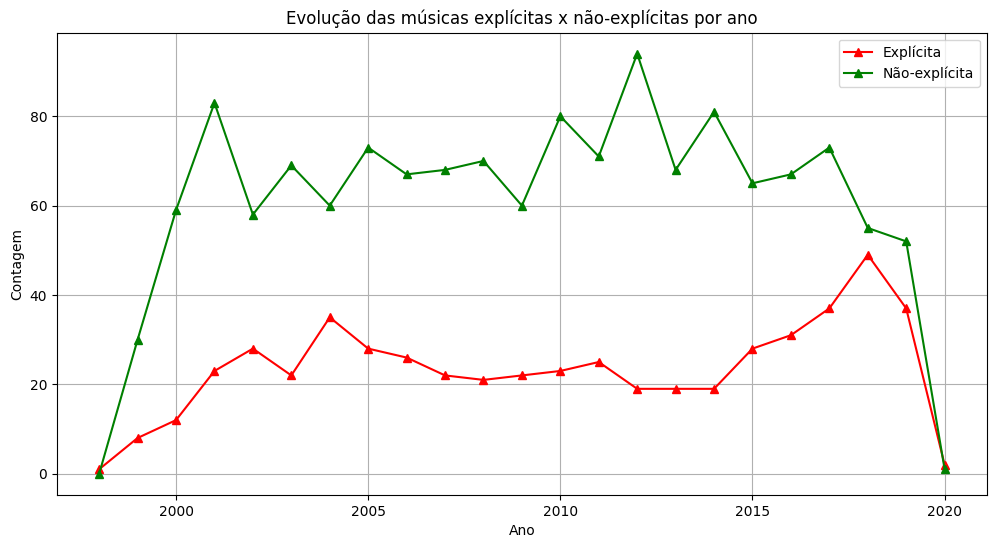

In [43]:
fig, ax = plt.subplots(figsize = (12, 6))
plt.plot(comp_spotify_explicit['year'], comp_spotify_explicit['Explicit'], marker = '^', label = 'Explícita', color = 'r')
plt.plot(comp_spotify_explicit['year'], comp_spotify_explicit['No-explicit'], marker = '^', label = 'Não-explícita', color = 'g')
plt.title('Evolução das músicas explícitas x não-explícitas por ano')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.grid()
plt.legend()
plt.show()

In [30]:
comp_spotify_explicit_genre = comp_spotify.groupby(['genre', 'explicit_label']).size().reset_index(name = 'count')
comp_spotify_explicit_genre = comp_spotify_explicit_genre.pivot_table(index = 'genre', columns= 'explicit_label', values = 'count').fillna(0).astype(int)
comp_spotify_explicit_genre.reset_index(inplace = True)
comp_spotify_explicit_genre

explicit_label,genre,Explicit,No-explicit
0,Dance/Electronic,7,34
1,"Folk/Acoustic, pop",0,2
2,"Folk/Acoustic, rock",0,1
3,"Folk/Acoustic, rock, pop",1,0
4,R&B,2,11
5,"World/Traditional, Folk/Acoustic",0,1
6,"World/Traditional, hip hop",1,1
7,"World/Traditional, pop",0,1
8,"World/Traditional, pop, Folk/Acoustic",0,2
9,"World/Traditional, rock",0,2


# **Correlações**

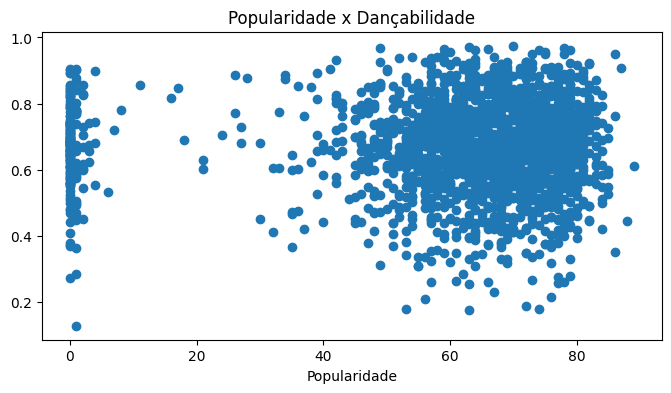

In [31]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['danceability'])
plt.title('Popularidade x Dançabilidade')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Dançabilidade → Músicas dançantes tendem a ser mais populares?**

Sim, existe uma tendência de músicas dançantes alcançarem maior popularidade, embora isso não seja uma regra absoluta. O gráfico mostra uma maior concentração de popularidade em faixas com um índice de dançabilidade acima de 0,6.

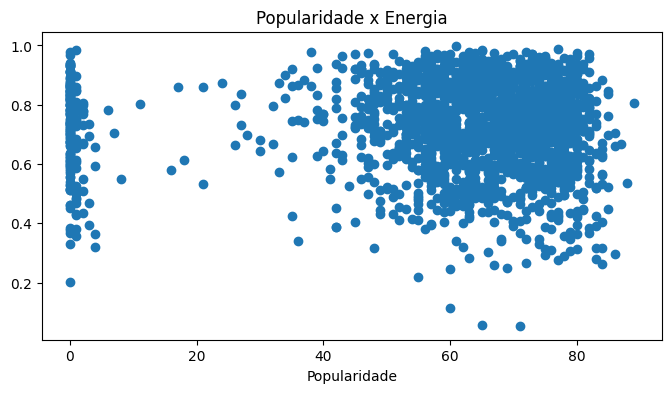

In [32]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['energy'])
plt.title('Popularidade x Energia')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Energia → Músicas mais intensas fazem mais sucesso?**

Há uma leve tendência positiva: músicas com mais energia geralmente têm maior popularidade. No entanto, também existem exceções com músicas de baixa energia e alta popularidade, indicando que a energia não é o único fator relevante.

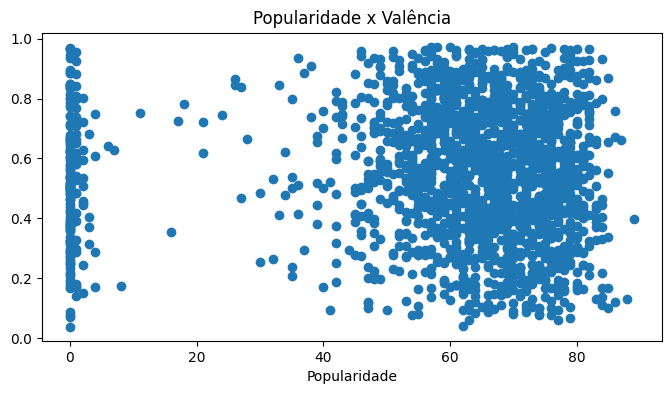

In [33]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['valence'])
plt.title('Popularidade x Valência')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Valência → O tom emocional afeta a popularidade?**

A relação é fraca. Músicas com diferentes tons emocionais (felizes ou tristes) podem fazer sucesso. O gráfico mostra uma baixa correlação entre valência e popularidade.

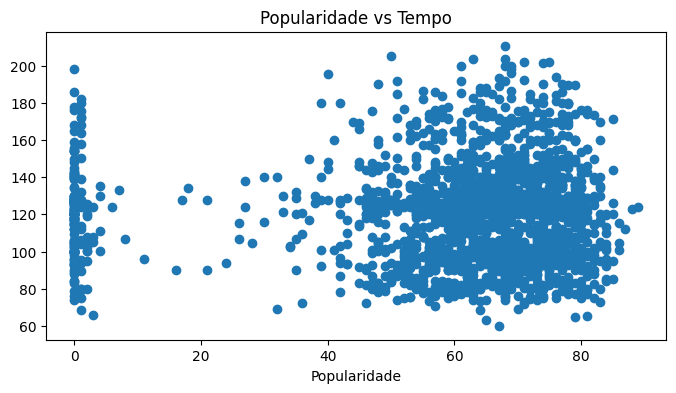

In [34]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['tempo'])
plt.title('Popularidade vs Tempo')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Tempo (bpm) → O tempo influencia o sucesso?**

Surpreendentemente, o gráfico mostra uma concentração de popularidade em faixas com BPM mais moderado ou baixo. Músicas muito rápidas parecem ser menos populares em geral.

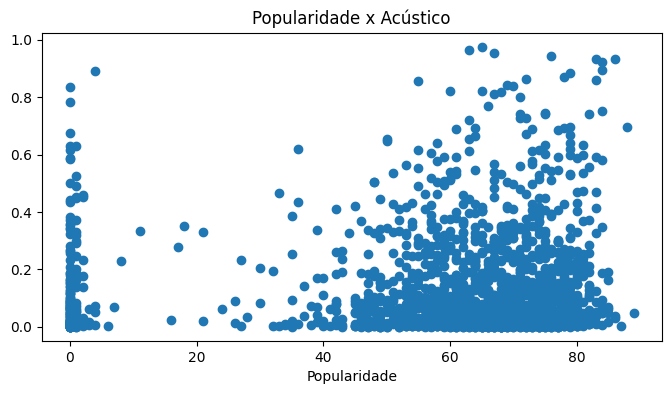

In [35]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['acousticness'])
plt.title('Popularidade x Acústico')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Acústica → Músicas mais acústicas são menos populares?**

Sim. A maioria das músicas populares não são acústicas. O gráfico mostra que músicas com alta acústica são menos frequentes entre as mais populares — com algumas exceções notáveis.

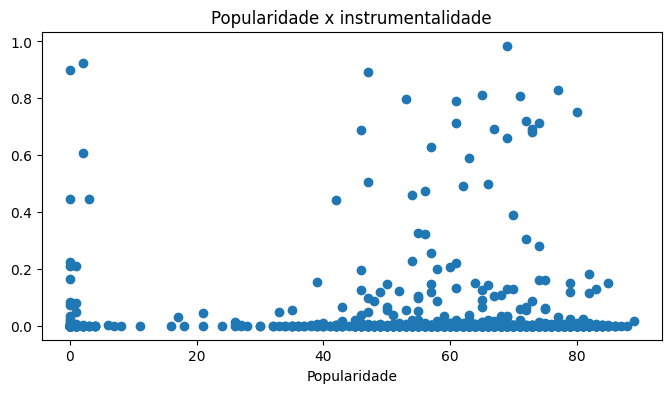

In [36]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['instrumentalness'])
plt.title('Popularidade x instrumentalidade')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Instrumentalidade → Músicas instrumentais são populares?**

A grande maioria das músicas populares tem poucas ou nenhuma característica instrumental. Músicas instrumentais raramente são populares — são a exceção, não a regra.

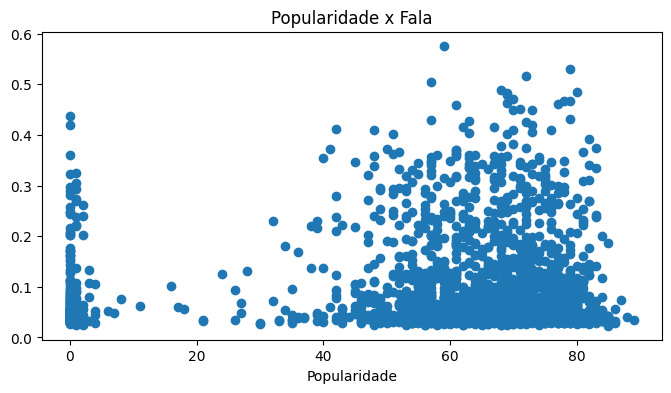

In [37]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['popularity'], spotify['speechiness'])
plt.title('Popularidade x Fala')
plt.xlabel('Popularidade')
plt.show()

**Popularidade × Fala → Músicas de spoken word ou rap fazem sucesso?**

A maioria das músicas populares tem pouca fala. No entanto, existem áreas com alta fala e alta popularidade, sugerindo que algumas músicas de rap ou spoken word também fazem sucesso — embora isso não seja a norma.

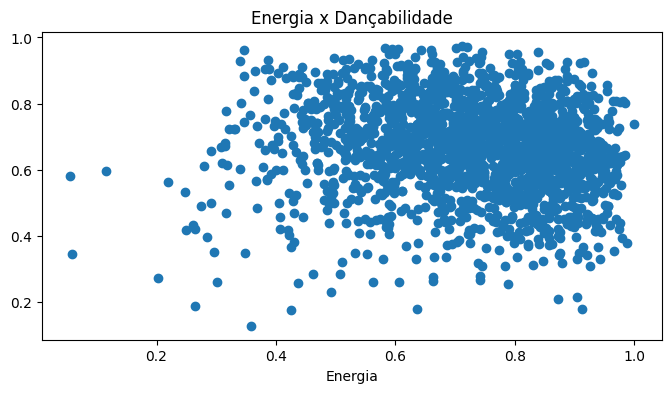

In [38]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['energy'], spotify['danceability'])
plt.title('Energia x Dançabilidade')
plt.xlabel('Energia')
plt.show()

**Energia × Dançabilidade → Músicas dançantes também são intensas?**

A correlação entre energia e dançabilidade é ligeiramente positiva — muitas músicas com alta energia também são dançantes, o que faz sentido em gêneros como pop e música eletrônica. No entanto, a dispersão no gráfico mostra que essa relação não é determinística: existem músicas dançantes com baixa energia e vice-versa. Portanto, a tendência existe, mas com variações importantes.

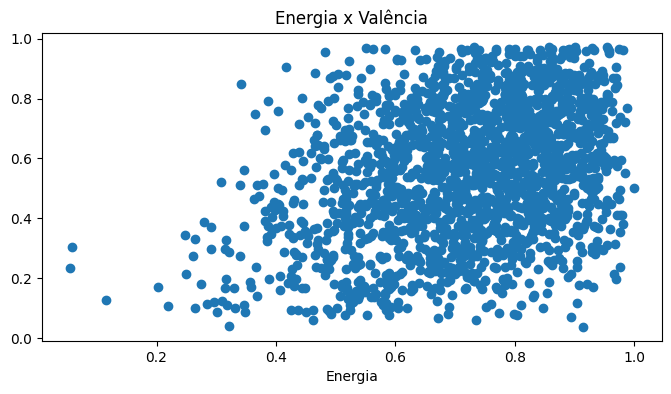

In [39]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['energy'], spotify['valence'])
plt.title('Energia x Valência')
plt.xlabel('Energia')
plt.show()

**Energia x Valência → As músicas felizes são mais enérgicas?**

O gráfico de dispersão mostra uma fraca relação entre valência (tom emocional positivo) e energia. Isso reforça a ideia de que músicas alegres nem sempre são intensas — por exemplo, uma música suave e animada pode ter alta valência e baixa energia, como baladas ou faixas acústicas. A correlação, se houver, é muito tênue.

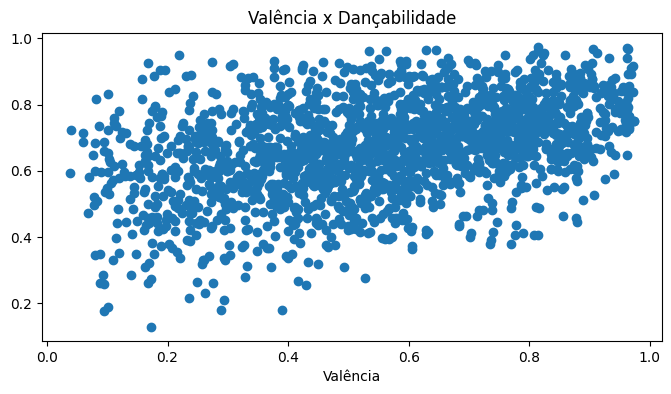

In [40]:
fig, ax = plt.subplots(figsize = (8, 4))
ax.scatter(spotify['valence'], spotify['danceability'])
plt.title('Valência x Dançabilidade')
plt.xlabel('Valência')
plt.show()

**Valência × Dançabilidade → Músicas alegres são mais dançantes?**

Aqui, a dispersão parece um pouco mais concentrada nas regiões de alta valência e dançabilidade, o que sugere uma leve correlação positiva. Isso indica que músicas mais alegres têm uma probabilidade ligeiramente maior de também serem dançantes — embora essa relação ainda não seja forte o suficiente para afirmar com certeza. É mais uma sugestão do que uma regra.